In [1]:
from MyPlotRecipe.SharedX import ShareXaxis
from MyPlotRecipe.UniversalColor import UniversalColor
from MyPlotRecipe.legend_shadow import legend_shadow
import numpy as np
import math
import datetime

from scipy import signal
import matplotlib.pyplot as plt
import matplotlib.ticker as ptick
from matplotlib.ticker import FixedLocator
from matplotlib.ticker import AutoMinorLocator
import matplotlib.dates as mdates

from CSField import CSField
import JupiterMag as jm

jm.Internal.Config(Model='jrm33', CartesianIn=True,
                   CartesianOut=True)
jm.Con2020.Config(equation_type='integral')

UC = UniversalColor()
UC.set_palette()

F = ShareXaxis()
F.fontsize = 23
F.fontname = 'Liberation Sans Narrow'
F.set_default()

Importing Library
done


In [2]:
def day2hhmm(decimal_day):
    doy = int(decimal_day)
    rest = decimal_day - doy

    hours = int(rest*24)
    minutes = (rest*24-hours)*60

    if round(minutes) >= 60:
        hours += 1
        minutes = 0
    else:
        minutes = round(minutes)
    return hours, minutes


def hhmm2day(hours, minutes, seconds=0):
    fraction_of_day = hours/24 + minutes/(60*24) + seconds/(60*60*24)
    return fraction_of_day


def fmt_hhmm(decimal_day):
    hours, minutes = day2hhmm(decimal_day)
    hh = '{:02}'.format(hours)
    mm = '{:02}'.format(minutes)
    return hh+':'+mm

In [3]:
# Data from Connerney+2020: PJ index
con20_pj_idx = np.array([1, 3, 4, 5, 6,
                        7, 8, 9, 10, 11,
                        12, 13, 14, 15, 16,
                        17, 18, 19, 20, 21,
                        22, 23, 24], dtype=int)

# Data from Connerney+2020: Current constant [nT]
con20_mu_i_tot = np.array([150.1, 137.8, 127.2, 129.1, 130.1,
                           142.3, 140.1, 143.8, 137.0, 141.4,
                           124.2, 148.9, 145.3, 144.8, 149.9,
                           132.1, 133.5, 152.9, 138.5, 138.8,
                           156.1, 141.4, 146.3])

# Data from Connerney+2020: Radial current constant [MA]
con20_mu_i_rho = np.array([35.2, 14.6, 7.7, 11.5, 20.8,
                           20.2, 12.2, 21.1, 20.9, 10.7,
                           26.26, 16.4, 12.0, 19.6, 12.0,
                           13.6, 20.0, 12.8, 16.0, 17.3,
                           9.9, 16.1, 10.3])

In [4]:
# 定数
RJ = 71492*1E+3  # Jupiter radius [m]
RE = 1560*1E+3   # Europa radius [m]
# Angular velocity of Jupiter System III rotation [rad sec-1]
OMG_J = 2*np.pi/(9.55*3600)
OMG_G = 2*np.pi/(7.2*24*3600)   # Ganymede orbital angular velosity [rad/sec]

In [5]:
PJ_list = [1, 3, 4, 5,
           6, 7, 8, 9, 10,
           11, 12, 13, 14, 15,
           16, 17, 18, 19, 20,
           21, 22, 23, 24, 25,
           26, 27, 28, 29, 30,
           32, 33, 34, 35,
           36, 37, 38, 39, 40,
           41, 42, 43, 44, 45,
           46, 48, 49, 50,
           51, 52, 53, 54, 55,
           56, 57, 58, 59, 60]
f0 = np.loadtxt('results/insitu_fit/result_PJ' +
                str(PJ_list[0]).zfill(2)+'_PJ'+str(PJ_list[-1]).zfill(2)+'.txt')

In [6]:
# %% Juno's perijove times
JUNO_PJ_TIMES = [
    datetime.datetime.strptime(
        '2016-08-27 12:50', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2016-10-19 18:10', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2016-12-11 17:03', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2017-02-02 12:57', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2017-03-27 08:51', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2017-05-19 06:00', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2017-07-11 01:54', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2017-09-01 21:48', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2017-10-24 17:42', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2017-12-16 17:56', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2018-02-07 13:51', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2018-04-01 09:45', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2018-05-24 05:39', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2018-07-16 05:17', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2018-09-07 01:11', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2018-10-29 21:05', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2018-12-21 16:59', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2019-02-12 17:34', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2019-04-06 12:14', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2019-05-29 08:08', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2019-07-21 04:02', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2019-09-12 03:40', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2019-11-03 22:18', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2019-12-26 17:36', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2020-02-17 17:51', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2020-04-10 13:47', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2020-06-02 10:20', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2020-07-25 06:15', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2020-09-16 02:10', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2020-11-08 01:49', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2020-12-30 21:45', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2021-02-21 17:40', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime('2021-04-15', '%Y-%m-%d'),
    datetime.datetime.strptime('2021-06-08', '%Y-%m-%d'),
    datetime.datetime.strptime('2021-07-21', '%Y-%m-%d'),
    datetime.datetime.strptime('2021-09-02', '%Y-%m-%d'),
    datetime.datetime.strptime('2021-10-16', '%Y-%m-%d'),
    datetime.datetime.strptime('2021-11-29', '%Y-%m-%d'),
    datetime.datetime.strptime('2022-01-12', '%Y-%m-%d'),
    datetime.datetime.strptime('2022-02-25', '%Y-%m-%d'),
    datetime.datetime.strptime('2022-04-09', '%Y-%m-%d'),
    datetime.datetime.strptime('2022-05-23', '%Y-%m-%d'),
    datetime.datetime.strptime('2022-07-05', '%Y-%m-%d'),
    datetime.datetime.strptime('2022-08-17', '%Y-%m-%d'),
    datetime.datetime.strptime('2022-09-29', '%Y-%m-%d'),
    datetime.datetime.strptime('2022-11-06', '%Y-%m-%d'),  # PJ46
    datetime.datetime.strptime('2022-12-15', '%Y-%m-%d'),  # PJ47
    datetime.datetime.strptime('2023-01-22', '%Y-%m-%d'),
    datetime.datetime.strptime('2023-03-01', '%Y-%m-%d'),
    datetime.datetime.strptime('2023-04-08', '%Y-%m-%d'),
    datetime.datetime.strptime('2023-05-16', '%Y-%m-%d'),
    datetime.datetime.strptime('2023-06-23', '%Y-%m-%d'),
    datetime.datetime.strptime('2023-07-31', '%Y-%m-%d'),
    datetime.datetime.strptime('2023-09-07', '%Y-%m-%d'),  # PJ54
    datetime.datetime.strptime('2023-10-15', '%Y-%m-%d'),
    datetime.datetime.strptime('2023-11-22', '%Y-%m-%d'),
    datetime.datetime.strptime('2023-12-30', '%Y-%m-%d'),
    datetime.datetime.strptime('2024-02-04', '%Y-%m-%d'),  # PJ58
    datetime.datetime.strptime('2024-03-07', '%Y-%m-%d'),
    datetime.datetime.strptime('2024-04-09', '%Y-%m-%d'),
    datetime.datetime.strptime('2024-05-12', '%Y-%m-%d'),
    datetime.datetime.strptime('2024-06-14', '%Y-%m-%d'),
    datetime.datetime.strptime('2024-07-16', '%Y-%m-%d'),
    datetime.datetime.strptime('2024-08-18', '%Y-%m-%d'),  # PJ64
    datetime.datetime.strptime('2024-09-20', '%Y-%m-%d'),
    datetime.datetime.strptime('2024-10-23', '%Y-%m-%d'),  # PJ66
]
JUNO_PJ_LABELS = ['PJ1', '', '', '', '',
                  '6', '', '', '', '',
                  '11', '', '', '', '',
                  '16', '', '', '', '',
                  '21', '', '', '', '',
                  '26', '', '', '', '',
                  '31', '', '', '', '',
                  '36', '', '', '', '',
                  '41', '', '', '', '',
                  '46', '', '', '', '',
                  '51', '', '', '', '',
                  '56', '', '', '', '',
                  '61', '', '', '', '',
                  '66']

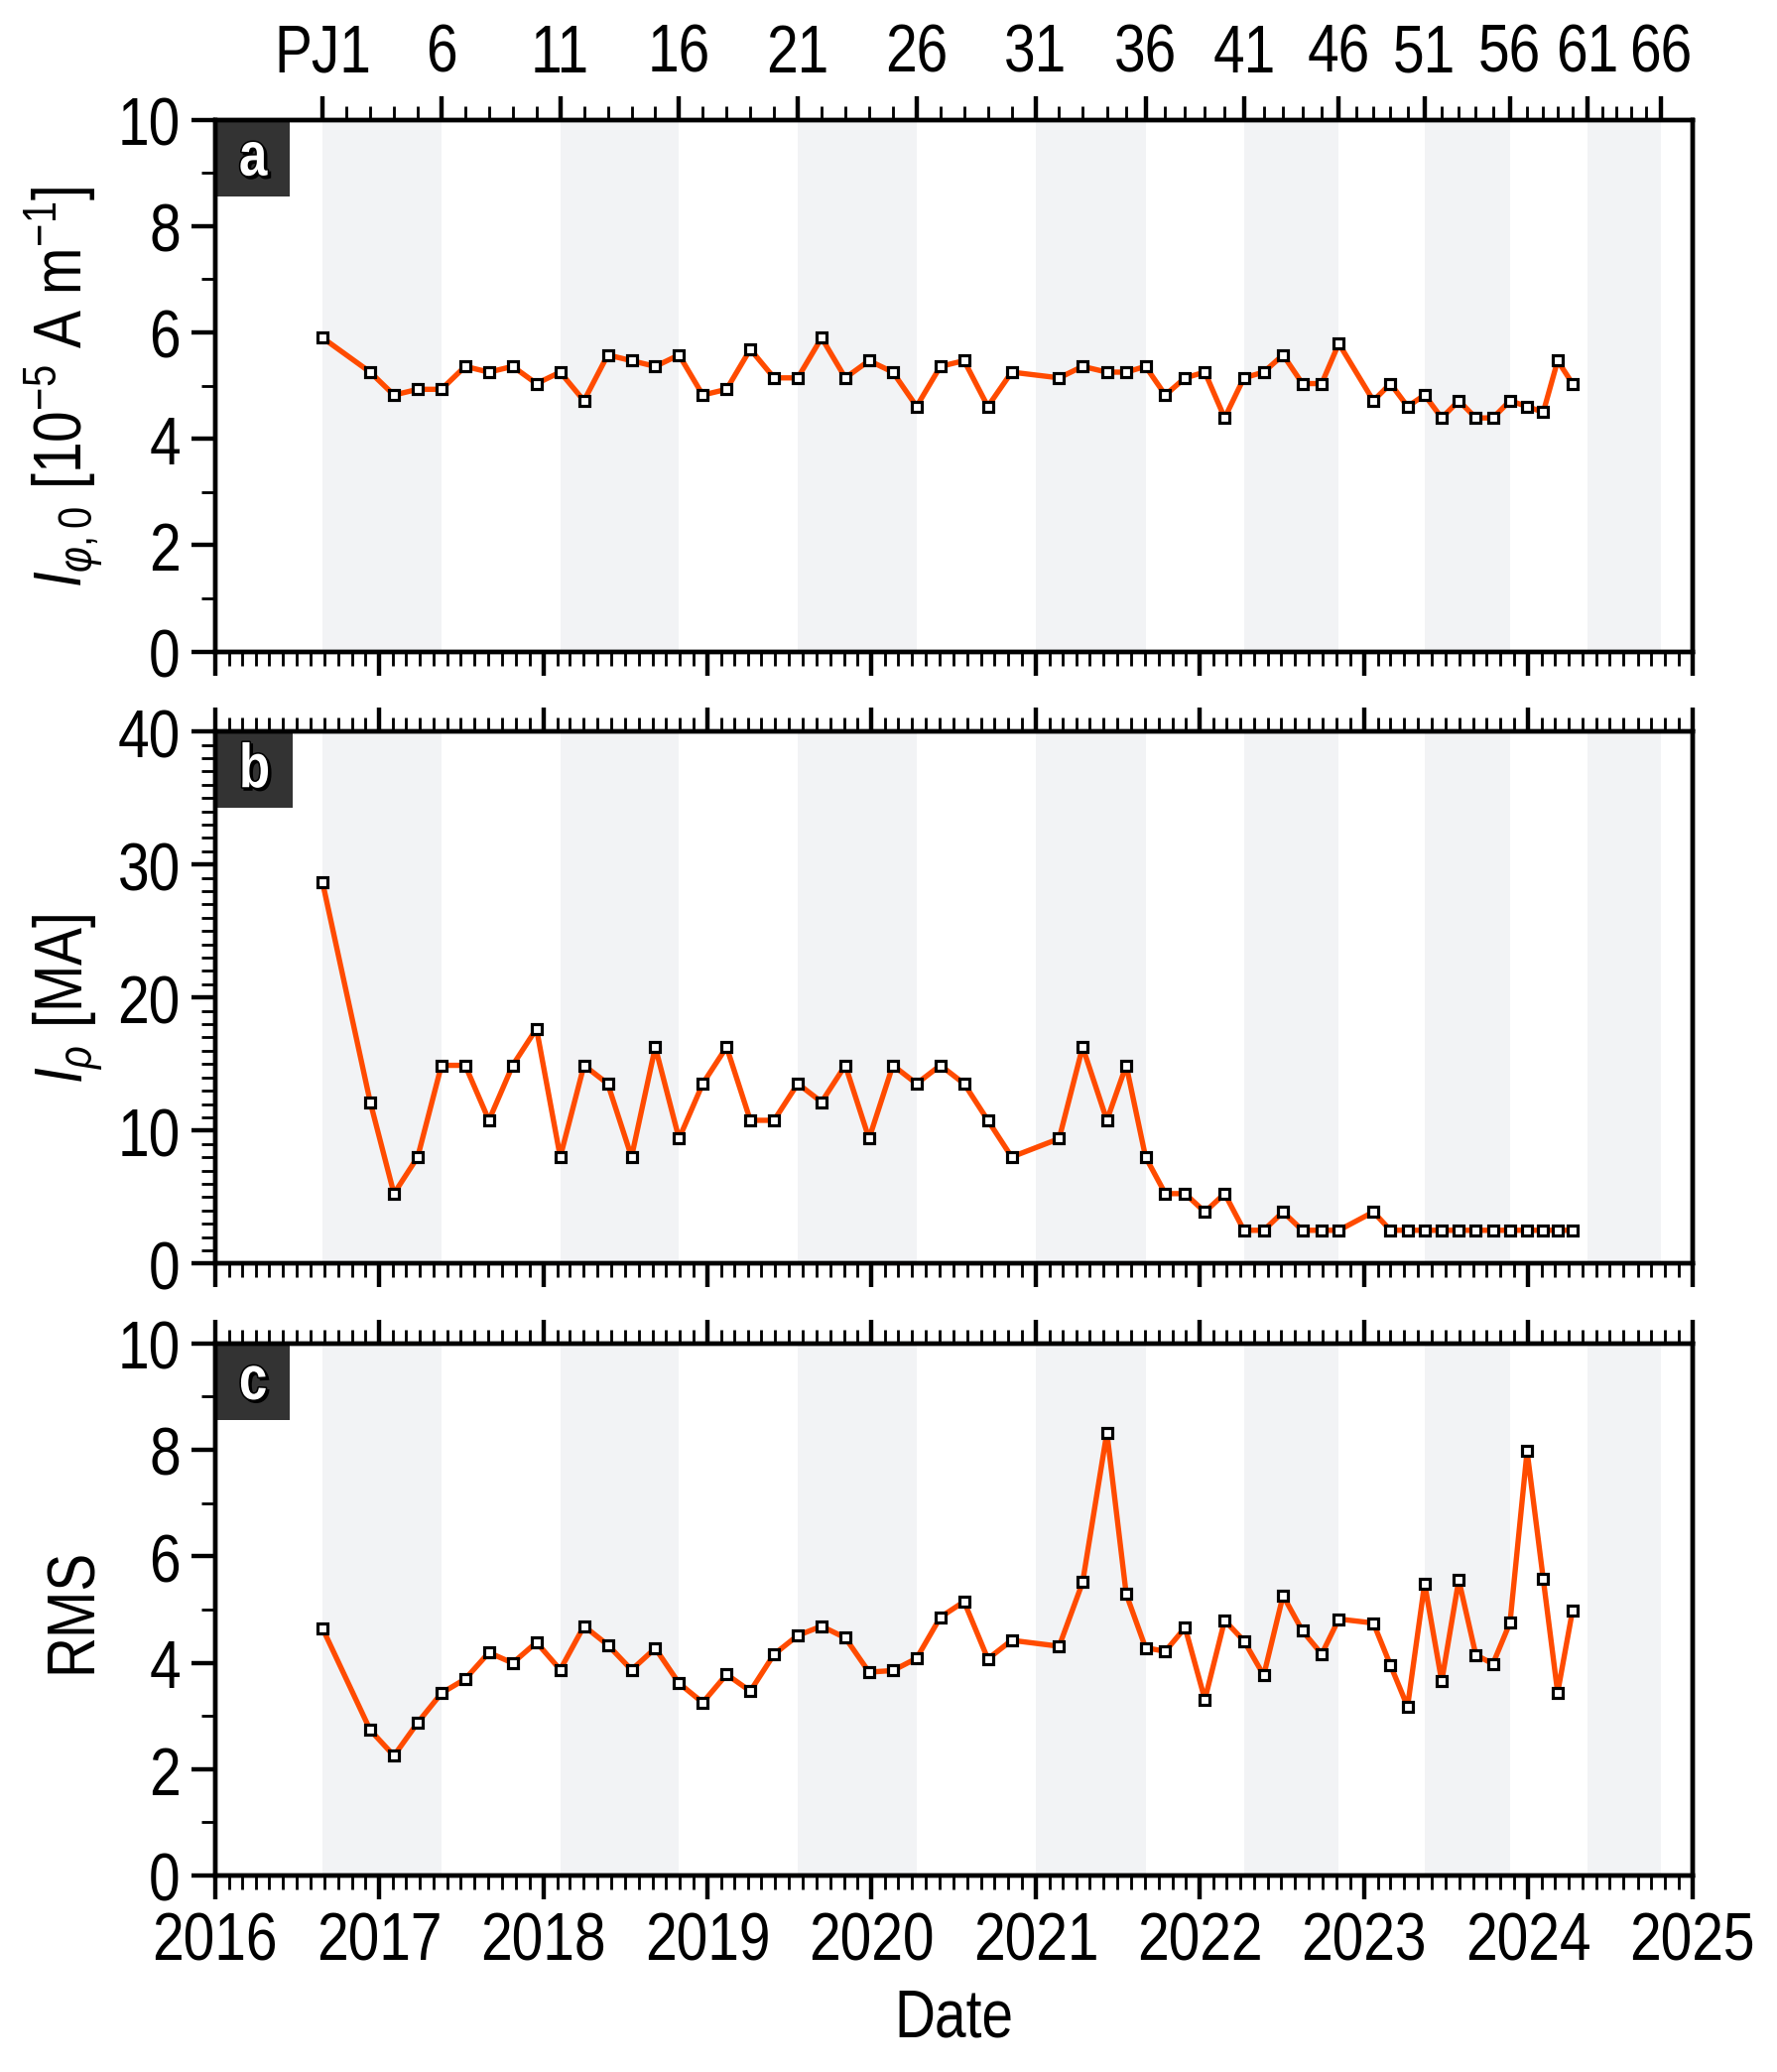

In [7]:
# %% ================================
# 横軸: date / 縦軸: 電流の沿磁力線積分値
# ===================================
F = ShareXaxis()
F.fontsize = 22
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=3, figsize=(8.0, 9.0), dpi='L')
F.hspace = 0.15
F.initialize()

sxmin = '2016-01-01'
sxmax = '2025-01-01'
xmin = datetime.datetime.strptime(sxmin, '%Y-%m-%d')
xmax = datetime.datetime.strptime(sxmax, '%Y-%m-%d')
xticks = [datetime.datetime.strptime('2016-01-01', '%Y-%m-%d'),
          datetime.datetime.strptime('2017-01-01', '%Y-%m-%d'),
          datetime.datetime.strptime('2018-01-01', '%Y-%m-%d'),
          datetime.datetime.strptime('2019-01-01', '%Y-%m-%d'),
          datetime.datetime.strptime('2020-01-01', '%Y-%m-%d'),
          datetime.datetime.strptime('2021-01-01', '%Y-%m-%d'),
          datetime.datetime.strptime('2022-01-01', '%Y-%m-%d'),
          datetime.datetime.strptime('2023-01-01', '%Y-%m-%d'),
          datetime.datetime.strptime('2024-01-01', '%Y-%m-%d'),
          datetime.datetime.strptime('2025-01-01', '%Y-%m-%d')]
xticklabels = ['2016', '2017', '2018', '2019', '2020',
               '2021', '2022', '2023', '2024', '2025']
F.set_xaxis(label='Date',
            min=xmin, max=xmax,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=12,
            format='%Y-%m-%d')
ticklabels = F.ax[2].get_xticklabels()
ticklabels[0].set_ha('center')
F.set_yaxis(ax_idx=0,
            label=r'$I_{\varphi,0}$ [$10^{-5}$ A m$^{-1}$]',
            min=0.0, max=10,
            ticks=np.arange(0, 10+1, 2),
            ticklabels=np.arange(0, 10+1, 2, dtype=int),
            minor_num=2,)
F.set_yaxis(ax_idx=1,
            label=r'$I_{\rho}$ [MA]',
            min=0.0, max=40,
            ticks=np.arange(0, 40+1, 10),
            ticklabels=np.arange(0, 40+1, 10),
            minor_num=10,)
F.set_yaxis(ax_idx=2,
            label=r'RMS',
            min=0.0, max=10,
            ticks=np.arange(0, 10+1, 2),
            ticklabels=np.arange(0, 10+1, 2),
            minor_num=2,)

# Azimuthal current
pj_2_date = []
for i in range(f0[:, 0].size):
    pj_2_date += [JUNO_PJ_TIMES[int(f0[i, 0])-1]]
F.ax[0].plot(pj_2_date, f0[:, 1]*1E+5, marker='s', color=UC.red, markersize=3,
             linewidth=1.7, markeredgecolor='k', markerfacecolor='w',
             zorder=2)

# Radial current
F.ax[1].plot(pj_2_date, f0[:, 2], marker='s', color=UC.red, markersize=3,
             linewidth=1.7, markeredgecolor='k', markerfacecolor='w',
             zorder=2)

# RMS
F.ax[2].plot(pj_2_date, f0[:, 3], marker='s', color=UC.red, markersize=3,
             linewidth=1.7, markeredgecolor='k', markerfacecolor='w',
             zorder=2)

# PJ numbers on the top horizontal axis
PJax = F.ax[0].twiny()
PJax.set_xlim(xmin, xmax)
PJax.set_xticks(JUNO_PJ_TIMES[::5])
PJax.set_xticklabels(JUNO_PJ_LABELS[::5])
PJax.xaxis.set_minor_locator(FixedLocator(mdates.date2num(JUNO_PJ_TIMES)))
PJax.tick_params('y', grid_zorder=-10)

# Shades in each 5 perijove
for i in range(3):
    F.ax[i].axvspan(JUNO_PJ_TIMES[0], JUNO_PJ_TIMES[5],
                    fc=UC.gray, ec=None, zorder=0.5, alpha=0.10)
    F.ax[i].axvspan(JUNO_PJ_TIMES[10], JUNO_PJ_TIMES[15],
                    fc=UC.gray, ec=None, zorder=0.5, alpha=0.10)
    F.ax[i].axvspan(JUNO_PJ_TIMES[20], JUNO_PJ_TIMES[25],
                    fc=UC.gray, ec=None, zorder=0.5, alpha=0.10)
    F.ax[i].axvspan(JUNO_PJ_TIMES[30], JUNO_PJ_TIMES[35],
                    fc=UC.gray, ec=None, zorder=0.5, alpha=0.10)
    F.ax[i].axvspan(JUNO_PJ_TIMES[40], JUNO_PJ_TIMES[45],
                    fc=UC.gray, ec=None, zorder=0.5, alpha=0.10)
    F.ax[i].axvspan(JUNO_PJ_TIMES[50], JUNO_PJ_TIMES[55],
                    fc=UC.gray, ec=None, zorder=0.5, alpha=0.10)
    F.ax[i].axvspan(JUNO_PJ_TIMES[60], JUNO_PJ_TIMES[65],
                    fc=UC.gray, ec=None, zorder=0.5, alpha=0.10)

"""legend = F.legend(ax_idx=0,
                  ncol=2, markerscale=1.0,
                  loc='lower center',
                  handlelength=0.85,
                  textcolor=False,
                  fontsize_scale=0.65,
                  handletextpad=0.35)
legend_shadow(legend=legend, fig=F.fig, ax=F.ax[0], d=0.7)"""

# F.fig.savefig(img_savedir + '/current_terms_timeseries_linear.jpg',
#               bbox_inches='tight')
plt.show()
F.close()
plt.close()